In [71]:
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
import json

## Load Data

In [72]:
race_data = pd.read_csv("race_data.csv")
drop_data  = pd.read_csv("drop_data.csv")
drop_data["Datetime"] = pd.to_datetime(drop_data["Datetime"])

with open("mapping_dicts.json", "r") as f:
    mappings = json.load(f)

race_to_id  = mappings["race_to_id"]
batch_to_id = mappings["batch_to_id"]
id_to_race  = {int(k): v for k, v in mappings["id_to_race"].items()}
id_to_batch = {int(k): v for k, v in mappings["id_to_batch"].items()}

model_data = drop_data.dropna(subset=["this_batch_dem_proportion"]).copy()
n_races    = len(race_data)
batches    = sorted(model_data["batch_id"].unique())

print(f"Races: {n_races}  |  Batches: {len(batches)}")

Races: 13  |  Batches: 24


## Load Saved MCMC Traces

In [73]:
model_traces = {}

for current_batch in batches:
    path = f"v2_traces/trace_batch_{current_batch}.nc"
    if os.path.exists(path):
        model_traces[current_batch] = az.from_netcdf(path)
    else:
        print(f"WARNING: missing trace for batch {current_batch}")

print(f"Loaded {len(model_traces)} traces.")

Loaded 24 traces.


## Extract Posterior Draws

In [74]:
baseline_array = race_data.sort_values("race_id")["baseline_dem_proportion"].values

extracted_posteriors = {}

for current_batch, trace in model_traces.items():
    s_r_raw       = trace.posterior["s_r"].values
    s_g_raw       = trace.posterior["s_g"].values
    sig_batch_raw = trace.posterior["sigma_batch"].values
    nu_raw        = trace.posterior["nu"].values

    s_r_flat       = s_r_raw.reshape(-1, s_r_raw.shape[-1])
    s_g_flat       = s_g_raw.flatten()
    sig_batch_flat = sig_batch_raw.flatten()
    nu_flat        = nu_raw.flatten()

    total_samples = len(s_g_flat)
    step = total_samples // 1000

    s_r_1000       = s_r_flat[::step][:1000]
    s_g_1000       = s_g_flat[::step][:1000]
    sig_batch_1000 = sig_batch_flat[::step][:1000]
    nu_1000        = nu_flat[::step][:1000]

    expected_b_1000 = s_r_1000 + s_g_1000[:, np.newaxis] + baseline_array

    extracted_posteriors[current_batch] = {
        "expected_b":  expected_b_1000,
        "sigma_batch": sig_batch_1000,
        "nu":          nu_1000
    }

print("Posteriors extracted for", len(extracted_posteriors), "batches.")

Posteriors extracted for 24 batches.


## Forward-Simulate Final Vote Totals

In [75]:
rng = np.random.default_rng(seed=42)

final_outcomes_dict      = {}
simulated_future_batches = {}

concentration_scale = 10.0
drift_slope         = 0.00
total_batches       = len(batches)

print("Projecting final totals for all batches...")

for i, current_batch in enumerate(batches):
    n_remaining = total_batches - i - 1

    cumulative_data = model_data[model_data["batch_id"] <= current_batch]
    current_data    = cumulative_data.sort_values("batch_id").drop_duplicates(subset=["race_id"], keep="last")

    current_dem_votes    = np.zeros(n_races)
    votes_remaining      = np.zeros(n_races)
    current_race_indices = current_data["race_id"].values
    current_dem_votes[current_race_indices] = current_data["up_to_this_batch_dem_votes"].values
    calc_remaining = current_data["final_total_votes"] - current_data["up_to_this_batch_total_votes"]
    votes_remaining[current_race_indices] = np.maximum(0, calc_remaining.values)

    if n_remaining > 0:
        log_weights     = np.log(1 + 1 / (np.arange(1, n_remaining + 1) - 0.5))
        alphas          = log_weights * concentration_scale
        dirichlet_draws = rng.dirichlet(alpha=alphas, size=(1000, n_races))
        dirichlet_draws = dirichlet_draws.transpose(0, 2, 1)
        sim_batch_sizes = dirichlet_draws * votes_remaining

        exp_b_1000     = extracted_posteriors[current_batch]["expected_b"]
        sig_batch_1000 = extracted_posteriors[current_batch]["sigma_batch"]
        nu_1000        = extracted_posteriors[current_batch]["nu"]

        exp_b_reshaped     = exp_b_1000[:, np.newaxis, :]
        sig_batch_reshaped = sig_batch_1000[:, np.newaxis, np.newaxis]
        nu_reshaped        = nu_1000[:, np.newaxis, np.newaxis]

        safe_sim_sizes = np.maximum(sim_batch_sizes.copy(), 1000.0)
        base_sigma     = sig_batch_reshaped / (safe_sim_sizes ** 0.25)
        k_values       = np.arange(1, n_remaining + 1)[np.newaxis, :, np.newaxis]
        total_sigma    = base_sigma * np.sqrt(1 + drift_slope * k_values)

        standard_t_draws = rng.standard_t(df=nu_reshaped, size=(1000, n_remaining, n_races))
        sim_dem_rates    = np.clip(exp_b_reshaped + standard_t_draws * total_sigma, 0.0, 1.0)
        simulated_future_batches[current_batch] = sim_dem_rates

        added_dem_votes = (sim_batch_sizes * sim_dem_rates).sum(axis=1)
        final_outcomes_dict[current_batch] = current_dem_votes + added_dem_votes
    else:
        final_outcomes_dict[current_batch]      = np.tile(current_dem_votes, (1000, 1))
        simulated_future_batches[current_batch] = None

batch_list        = list(final_outcomes_dict.keys())
race_denominators = race_data.sort_values("race_id")["final_total_votes"].values

print("Projection complete.")
# Map batch_id -> actual E+i days (from drop_data real dates, not a formula)
election_day = pd.Timestamp('2024-11-05')
batch_ei = (
    drop_data.groupby('batch_id')['Datetime'].min()
    .dt.normalize()
    .apply(lambda d: int((d - election_day).days))
    .to_dict()
)
# batch 0 = Nov 8 = E+3; batch 1 = Nov 9 = E+4; etc.
print('batch_ei sample:', {k: batch_ei[k] for k in sorted(batch_ei)[:5]})

Projecting final totals for all batches...
Projection complete.
batch_ei sample: {0: 3, 1: 4, 2: 5, 3: 6, 4: 7}


## CD-13 and CD-45: Vote Share + Win Probability

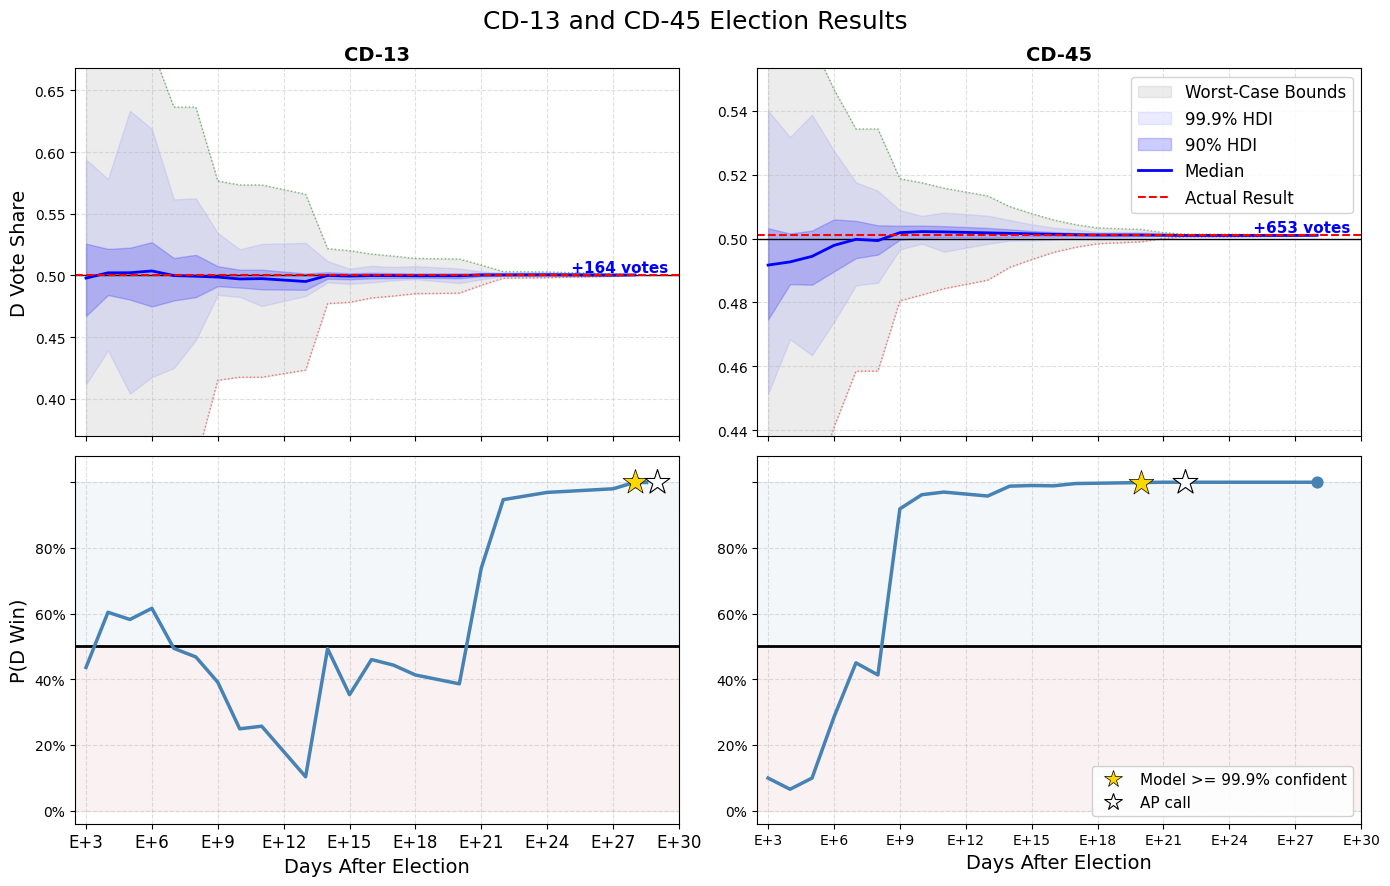

In [76]:
focus_races   = ["CD-13", "CD-45"]
focus_indices = [k for k, v in id_to_race.items() if v in focus_races]
focus_indices = sorted(focus_indices, key=lambda i: id_to_race[i])

margins = {"CD-13": "+164", "CD-45": "+653"}

# AP call dates -> E+i
election_day = pd.Timestamp('2024-11-05')
ap_dates  = {"CD-13": pd.Timestamp('2024-12-04'),
             "CD-45": pd.Timestamp('2024-11-27')}
ap_ei_map = {k: (v - election_day).days for k, v in ap_dates.items()}

# One point per calendar day: keep the LAST batch that fell on each day
# This removes duplicate x values when two drops occurred on the same day
day_to_batch = {}   # ei -> batch_id (last batch of that day)
for b in batch_list:
    day_to_batch[batch_ei[b]] = b
unique_days = sorted(day_to_batch.keys())

max_data_ei = max(unique_days)
max_ap_ei   = max(ap_ei_map.values())
x_right     = max(max_data_ei, max_ap_ei) + 1

tick_positions = list(range(3, x_right + 3, 3))
tick_labels    = [f"E+{i}" for i in tick_positions]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

for col, race_idx in enumerate(focus_indices):
    race_name        = id_to_race[race_idx]
    race_denominator = race_denominators[race_idx]
    actual_final_prop = race_data[race_data["race_id"] == race_idx]["final_dem_proportion"].values[0]
    dem_won = actual_final_prop > 0.5
    ap_ei   = ap_ei_map.get(race_name)

    p00, p05, p50, p95, p999 = [], [], [], [], []
    min_bounds, max_bounds, p_win = [], [], []

    for ei in unique_days:
        b         = day_to_batch[ei]
        sims_prop = final_outcomes_dict[b][:, race_idx] / race_denominator
        p00.append(np.percentile(sims_prop, 0.5))
        p05.append(np.percentile(sims_prop, 5))
        p50.append(np.percentile(sims_prop, 50))
        p95.append(np.percentile(sims_prop, 95))
        p999.append(np.percentile(sims_prop, 99.9))
        p_win.append(np.mean(sims_prop > 0.5))

        cum_data = model_data[(model_data["batch_id"] <= b) & (model_data["race_id"] == race_idx)]
        if len(cum_data) > 0:
            current_dem   = cum_data["up_to_this_batch_dem_votes"].iloc[-1]
            current_total = cum_data["up_to_this_batch_total_votes"].iloc[-1]
        else:
            baseline_data = race_data[race_data["race_id"] == race_idx]
            current_dem   = baseline_data["baseline_dem_votes"].values[0]
            current_total = baseline_data["baseline_total_votes"].values[0]

        rem_votes = race_denominator - current_total
        min_bounds.append(current_dem / race_denominator)
        max_bounds.append((current_dem + rem_votes) / race_denominator)

    # --- Row 0: D Vote Share ---
    ax_top = axes[0, col]
    ax_top.fill_between(unique_days, min_bounds, max_bounds, color="gray", alpha=0.15, label="Worst-Case Bounds")
    ax_top.plot(unique_days, max_bounds, color="green", linestyle=":", alpha=0.5, linewidth=1)
    ax_top.plot(unique_days, min_bounds, color="red",   linestyle=":", alpha=0.5, linewidth=1)
    ax_top.axhline(0.5, color="black", linewidth=1, zorder=2)
    ax_top.fill_between(unique_days, p00, p999, color="blue", alpha=0.08, label="99.9% HDI")
    ax_top.fill_between(unique_days, p05, p95,  color="blue", alpha=0.2,  label="90% HDI")
    ax_top.plot(unique_days, p50, color="blue", linewidth=2, label="Median")
    ax_top.axhline(actual_final_prop, color="red", linestyle="--", linewidth=1.5, label="Actual Result")

    margin_text = margins.get(race_name, "")
    if margin_text:
        ax_top.text(x_right - 0.5, actual_final_prop, f" {margin_text} votes",
                    color="blue", fontsize=11, va="bottom", ha="right", fontweight="bold")

    sim_min  = min(p00);  sim_max = max(p999)
    plot_min = min(sim_min, actual_final_prop)
    plot_max = max(sim_max, actual_final_prop)
    y_range  = plot_max - plot_min
    padding  = y_range * 0.15 if y_range > 0 else 0.05
    ax_top.set_ylim(plot_min - padding, plot_max + padding)
    ax_top.set_title(race_name, fontsize=14, fontweight="bold")
    ax_top.grid(True, linestyle="--", alpha=0.4)
    if col == 0:
        ax_top.set_ylabel("D Vote Share", fontsize=14)
    if col == 1:
        ax_top.legend(loc="best", fontsize=12, framealpha=0.85)

    # --- Row 1: P(D Win) ---
    ax_bot = axes[1, col]
    ax_bot.axhspan(0.5, 1.0, color="steelblue", alpha=0.06)
    ax_bot.axhspan(0.0, 0.5, color="firebrick", alpha=0.06)
    ax_bot.axhline(0.5, color="black", linewidth=2.0, zorder=3)

    ax_bot.plot(unique_days, p_win, color="steelblue", linewidth=2.5, zorder=4)
    ax_bot.scatter([unique_days[-1]], [p_win[-1]],
                   color="steelblue" if dem_won else "firebrick", s=60, zorder=5)

    # Gold star: first day model crosses threshold
    first_999_idx = next((j for j, p in enumerate(p_win) if p >= 0.999), None)
    if first_999_idx is not None:
        ax_bot.scatter([unique_days[first_999_idx]], [p_win[first_999_idx]],
                       marker="*", color="gold", s=350, zorder=7, edgecolors="black", linewidths=0.5)

    # White star: AP call — extend as dashed line if after last data day
    if ap_ei is not None:
        if ap_ei > max_data_ei:
            ax_bot.plot([max_data_ei, ap_ei], [p_win[-1], p_win[-1]],
                        color="steelblue", linewidth=2.5, linestyle="--", zorder=4)
            ap_y = p_win[-1]
        else:
            closest_i = min(range(len(unique_days)), key=lambda j: abs(unique_days[j] - ap_ei))
            ap_y = p_win[closest_i]
        ax_bot.scatter([ap_ei], [ap_y],
                       marker="*", color="white", s=350, zorder=8, edgecolors="black", linewidths=0.8)

    ax_bot.set_ylim(-0.04, 1.08)
    ax_bot.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}" if 0 <= y <= 1 else ""))
    ax_bot.grid(True, linestyle="--", alpha=0.4)
    ax_bot.set_xlabel("Days After Election", fontsize=14)
    if col == 0:
        ax_bot.set_ylabel("P(D Win)", fontsize=14)

axes[0, 0].set_xlim(left=unique_days[0] - 0.5, right=x_right)
axes[1, 0].set_xticks(tick_positions)
axes[1, 0].set_xticklabels(tick_labels, rotation=0, ha="center", fontsize=12)

star_legend = [
    Line2D([0],[0], marker="*", color="w", markerfacecolor="gold",  markersize=13,
           markeredgecolor="black", markeredgewidth=0.5, label="Model >= 99.9% confident"),
    Line2D([0],[0], marker="*", color="w", markerfacecolor="white", markersize=13,
           markeredgecolor="black", markeredgewidth=0.8, label="AP call"),
]
axes[1, 1].legend(handles=star_legend, loc="lower right", fontsize=11, framealpha=0.9)

plt.suptitle("CD-13 and CD-45 Election Results", fontsize=18)
plt.tight_layout()
plt.show()

## Model Call vs AP Call: How Early Did We Call Each Race?

In [82]:
# Build batch -> date lookup from drop_data
batch_dates = drop_data.groupby("batch_id")["Datetime"].min().dt.normalize()

# Load AP call dates
# races_called.csv has a trailing comma (extra column) and a space in the date header
ap_df = pd.read_csv("../races_called.csv")
ap_df.columns = ap_df.columns.str.strip()
ap_df["race"] = ap_df["race"].str.strip()
ap_df["date_called"] = pd.to_datetime(ap_df["date_called"].str.strip(), format="%m-%d-%Y")
ap_calls = ap_df.set_index("race")["date_called"].to_dict()

# Find first batch where each modeled race crosses either threshold:
#   P(D Win) >= 99.9%  -> call for Democrat
#   P(D Win) <=  0.1%  -> call for Republican
rows = []

for race_idx in sorted(id_to_race.keys()):
    race_name        = id_to_race[race_idx]
    race_denominator = race_denominators[race_idx]

    model_call_batch = None
    model_call_date  = None
    model_call_dir   = None
    final_p_win      = None

    for b in batch_list:
        sims_prop = final_outcomes_dict[b][:, race_idx] / race_denominator
        p_win     = np.mean(sims_prop > 0.5)
        final_p_win = p_win
        if model_call_batch is None:
            if p_win >= 0.99:
                model_call_batch = b
                model_call_date  = batch_dates.get(b)
                model_call_dir   = "D"
            elif p_win <= 0.01:
                model_call_batch = b
                model_call_date  = batch_dates.get(b)
                model_call_dir   = "R"

    ap_date = ap_calls.get(race_name)

    # days_ahead: positive means model called it BEFORE AP
    if model_call_date is not None and ap_date is not None:
        days_ahead = (ap_date - model_call_date).days
    else:
        days_ahead = None

    rows.append({
        "Race":             race_name,
        "Call":             model_call_dir if model_call_dir else "—",
        "Model Call Date":  model_call_date.strftime("%b %d") if model_call_date else "Never",
        "AP Call Date":     ap_date.strftime("%b %d")         if ap_date         else "—",
        "Days Ahead of AP": days_ahead,
        "Final P(Win)":     f"{final_p_win:.1%}"              if final_p_win is not None else "—",
    })

results_df = pd.DataFrame(rows)

valid_diffs = results_df["Days Ahead of AP"].dropna()
avg_ahead   = valid_diffs.mean()

display(results_df.to_string(index=False))
print(f"\nAverage days model called it BEFORE AP (n={len(valid_diffs)}): {avg_ahead:.1f}")
print("(positive = model was earlier; negative = model was later)")

' Race Call Model Call Date AP Call Date  Days Ahead of AP Final P(Win)\nAD-58    R          Nov 22            —               NaN         0.0%\nCD-13    D          Dec 03       Dec 04               1.0       100.0%\nCD-21    D          Nov 14       Nov 15               1.0       100.0%\nCD-22    R          Nov 12       Nov 12               0.0         0.0%\nCD-40    R          Nov 08       Nov 07              -1.0         0.0%\nCD-41    R          Nov 08       Nov 13               5.0         0.0%\nCD-45    D          Nov 20       Nov 27               7.0       100.0%\nCD-47    D          Nov 14       Nov 13              -1.0       100.0%\nCD-49    D          Nov 09       Nov 12               3.0       100.0%\n CD-9    D          Nov 14       Nov 15               1.0       100.0%\nSD-19    R          Nov 12       Nov 14               2.0         0.0%\nSD-37    R          Nov 14       Nov 25              11.0         0.0%\n SD-5    D          Nov 14       Nov 15               1.0      


Average days model called it BEFORE AP (n=12): 2.5
(positive = model was earlier; negative = model was later)


In [83]:
results_df

,Race,Call,Model Call Date,AP Call Date,Days Ahead of AP,Final P(Win)
0,AD-58,R,Nov 22,—,NaN,0.0%
1,CD-13,D,Dec 03,Dec 04,1.0,100.0%
2,CD-21,D,Nov 14,Nov 15,1.0,100.0%
3,CD-22,R,Nov 12,Nov 12,0.0,0.0%
4,CD-40,R,Nov 08,Nov 07,-1.0,0.0%
5,CD-41,R,Nov 08,Nov 13,5.0,0.0%
6,CD-45,D,Nov 20,Nov 27,7.0,100.0%
7,CD-47,D,Nov 14,Nov 13,-1.0,100.0%
8,CD-49,D,Nov 09,Nov 12,3.0,100.0%
9,CD-9,D,Nov 14,Nov 15,1.0,100.0%


In [84]:
results_df['Days Ahead of AP'].iloc[1:10].mean()

np.float64(1.7777777777777777)

## P(D Win) Over Time — Races the Model Never Called

In [ ]:
uncalled = results_df[results_df["Model Call Date"] == "Never"]["Race"].tolist()
print(f"{len(uncalled)} uncalled races: {uncalled}")

if not uncalled:
    print("Model called every race.")
else:
    cols_n = min(3, len(uncalled))
    rows_n = int(np.ceil(len(uncalled) / cols_n))
    fig, axes = plt.subplots(rows_n, cols_n, figsize=(6 * cols_n, 4 * rows_n),
                             sharey=True, squeeze=False)

    plotted_batches = batch_list
    tick_positions  = list(range(0, max(plotted_batches) + 1, 3))
    tick_labels     = [f"E+{batch_ei[b]}" for b in tick_positions]

    for ax_idx, race_name in enumerate(uncalled):
        ax  = axes[ax_idx // cols_n][ax_idx % cols_n]
        race_idx = next(k for k, v in id_to_race.items() if v == race_name)
        race_denominator  = race_denominators[race_idx]
        actual_final_prop = race_data[race_data["race_id"] == race_idx]["final_dem_proportion"].values[0]
        dem_won = actual_final_prop > 0.5

        p_win = [np.mean(final_outcomes_dict[b][:, race_idx] / race_denominator > 0.5)
                 for b in batch_list]

        ax.axhspan(0.5, 1.0, color="steelblue", alpha=0.06)
        ax.axhspan(0.0, 0.5, color="firebrick", alpha=0.06)
        ax.axhline(0.5,   color="black", linewidth=2.0, zorder=3)
        ax.axhline(0.999, color="gold",  linewidth=1.2, linestyle="--", alpha=0.8, zorder=2)
        ax.axhline(0.001, color="gold",  linewidth=1.2, linestyle="--", alpha=0.8, zorder=2)

        ax.plot(plotted_batches, p_win, color="steelblue", linewidth=2.5, zorder=4)
        ax.scatter([plotted_batches[-1]], [p_win[-1]],
                   color="steelblue" if dem_won else "firebrick", s=60, zorder=5)

        ap_date = ap_calls.get(race_name)
        if ap_date is not None:
            ap_batch = (batch_dates - ap_date).abs().idxmin()
            if ap_batch in plotted_batches:
                ap_i = list(plotted_batches).index(ap_batch)
                ax.scatter([plotted_batches[ap_i]], [p_win[ap_i]],
                           marker="*", color="white", s=300, zorder=6,
                           edgecolors="black", linewidths=0.8)

        ax.set_ylim(-0.04, 1.08)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}" if 0 <= y <= 1 else ""))
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=0, ha="center", fontsize=9)
        ax.set_title(race_name, fontsize=13, fontweight="bold")
        ax.grid(True, linestyle="--", alpha=0.4)
        if ax_idx % cols_n == 0:
            ax.set_ylabel("P(D Win)", fontsize=12)
        ax.set_xlabel("Days After Election", fontsize=11)

    for j in range(len(uncalled), rows_n * cols_n):
        axes[j // cols_n][j % cols_n].set_visible(False)

    plt.suptitle("Races the Model Never Called (P(D Win) stayed between 0.1% and 99.9%)",
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

0 uncalled races: []
Model called every race.


## Earliest and Latest Model Calls vs AP

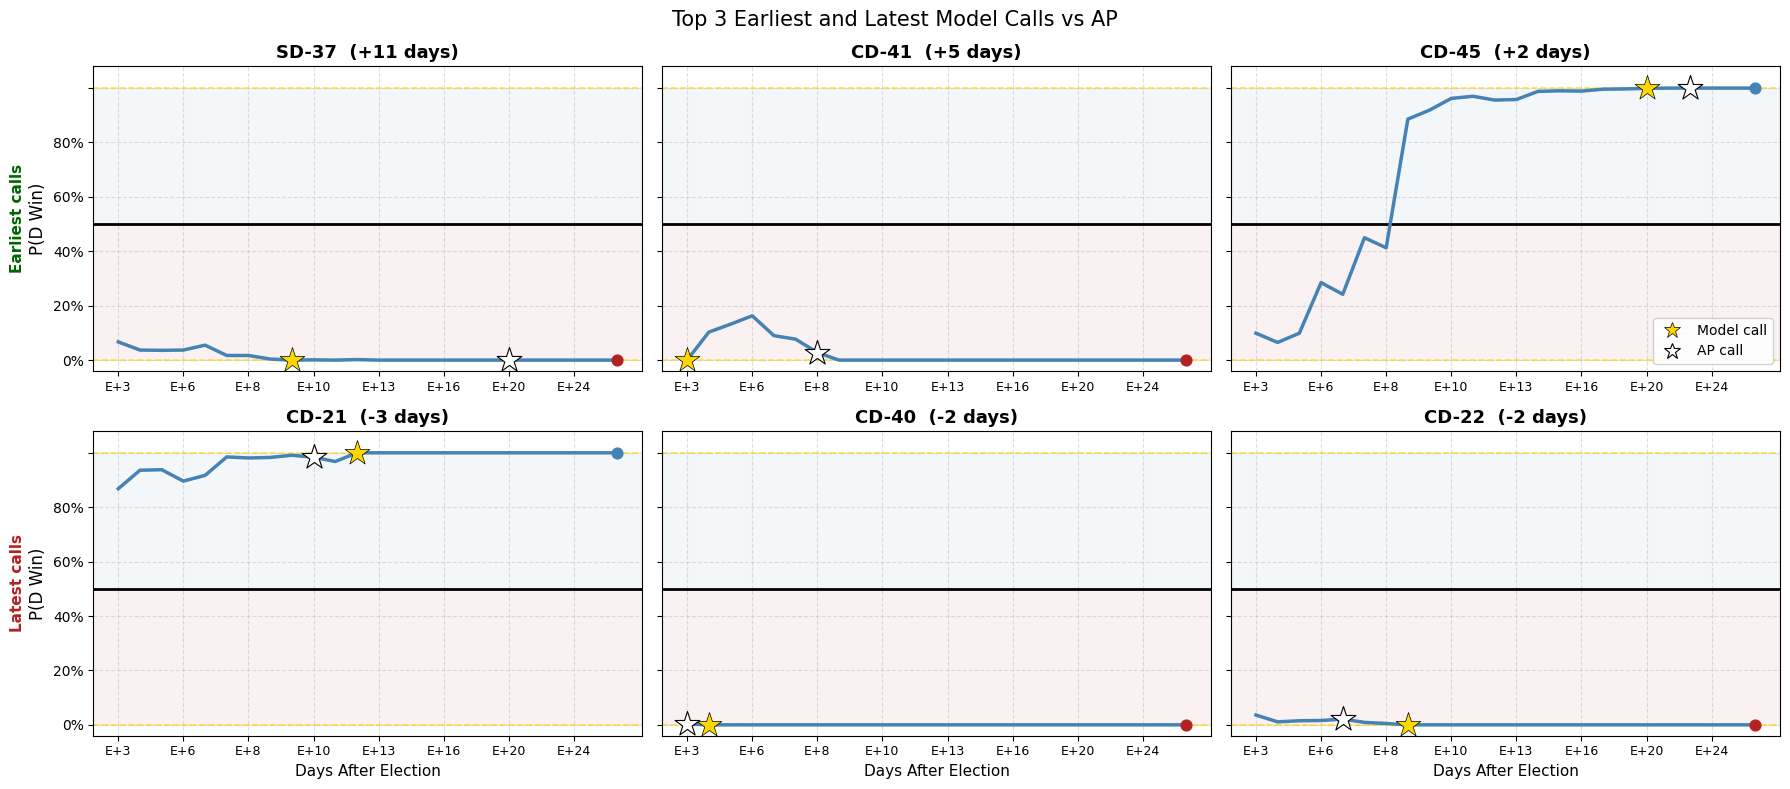

In [ ]:
ranked  = results_df.dropna(subset=["Days Ahead of AP"]).sort_values("Days Ahead of AP", ascending=False)
top3    = ranked.head(3)
bottom3 = ranked.tail(3).iloc[::-1]
focus   = pd.concat([top3, bottom3])

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey=True)

plotted_batches = batch_list
tick_positions  = list(range(0, max(plotted_batches) + 1, 3))
tick_labels     = [f"E+{batch_ei[b]}" for b in tick_positions]

for ax_idx, (_, row) in enumerate(focus.iterrows()):
    ax        = axes[ax_idx // 3][ax_idx % 3]
    race_name = row["Race"]
    race_idx  = next(k for k, v in id_to_race.items() if v == race_name)
    race_denominator  = race_denominators[race_idx]
    actual_final_prop = race_data[race_data["race_id"] == race_idx]["final_dem_proportion"].values[0]
    dem_won = actual_final_prop > 0.5

    p_win = [np.mean(final_outcomes_dict[b][:, race_idx] / race_denominator > 0.5)
             for b in batch_list]

    model_call_batch = next((b for b in batch_list
                             if np.mean(final_outcomes_dict[b][:, race_idx] / race_denominator > 0.5) >= 0.999
                             or np.mean(final_outcomes_dict[b][:, race_idx] / race_denominator > 0.5) <= 0.001),
                            None)

    ax.axhspan(0.5, 1.0, color="steelblue", alpha=0.06)
    ax.axhspan(0.0, 0.5, color="firebrick", alpha=0.06)
    ax.axhline(0.5,   color="black", linewidth=2.0, zorder=3)
    ax.axhline(0.999, color="gold",  linewidth=1.2, linestyle="--", alpha=0.7, zorder=2)
    ax.axhline(0.001, color="gold",  linewidth=1.2, linestyle="--", alpha=0.7, zorder=2)

    ax.plot(plotted_batches, p_win, color="steelblue", linewidth=2.5, zorder=4)
    ax.scatter([plotted_batches[-1]], [p_win[-1]],
               color="steelblue" if dem_won else "firebrick", s=60, zorder=5)

    if model_call_batch is not None:
        mc_i = list(plotted_batches).index(model_call_batch)
        ax.scatter([plotted_batches[mc_i]], [p_win[mc_i]],
                   marker="*", color="gold", s=350, zorder=7, edgecolors="black", linewidths=0.5)

    ap_date = ap_calls.get(race_name)
    if ap_date is not None:
        ap_batch = (batch_dates - ap_date).abs().idxmin()
        if ap_batch in plotted_batches:
            ap_i = list(plotted_batches).index(ap_batch)
            ax.scatter([plotted_batches[ap_i]], [p_win[ap_i]],
                       marker="*", color="white", s=350, zorder=8, edgecolors="black", linewidths=0.8)

    days = int(row["Days Ahead of AP"])
    sign = f"+{days}" if days >= 0 else str(days)
    ax.set_title(f"{race_name}  ({sign} days)", fontsize=13, fontweight="bold")
    ax.set_ylim(-0.04, 1.08)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}" if 0 <= y <= 1 else ""))
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=0, ha="center", fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)
    if ax_idx % 3 == 0:
        ax.set_ylabel("P(D Win)", fontsize=12)
    if ax_idx >= 3:
        ax.set_xlabel("Days After Election", fontsize=11)

axes[0][0].annotate("Earliest calls", xy=(0, 0.5), xytext=(-60, 0),
                    xycoords="axes fraction", textcoords="offset points",
                    fontsize=11, color="darkgreen", fontweight="bold", va="center", rotation=90)
axes[1][0].annotate("Latest calls", xy=(0, 0.5), xytext=(-60, 0),
                    xycoords="axes fraction", textcoords="offset points",
                    fontsize=11, color="firebrick", fontweight="bold", va="center", rotation=90)

from matplotlib.lines import Line2D
legend_els = [
    Line2D([0],[0], marker="*", color="w", markerfacecolor="gold",  markersize=12,
           markeredgecolor="black", markeredgewidth=0.5, label="Model call"),
    Line2D([0],[0], marker="*", color="w", markerfacecolor="white", markersize=12,
           markeredgecolor="black", markeredgewidth=0.8, label="AP call"),
]
axes[0][2].legend(handles=legend_els, fontsize=10, loc="lower right", framealpha=0.9)

plt.suptitle("Top 3 Earliest and Latest Model Calls vs AP", fontsize=15)
plt.tight_layout()
plt.show()

## All 13 Modeled Races: P(D Win) Over Time

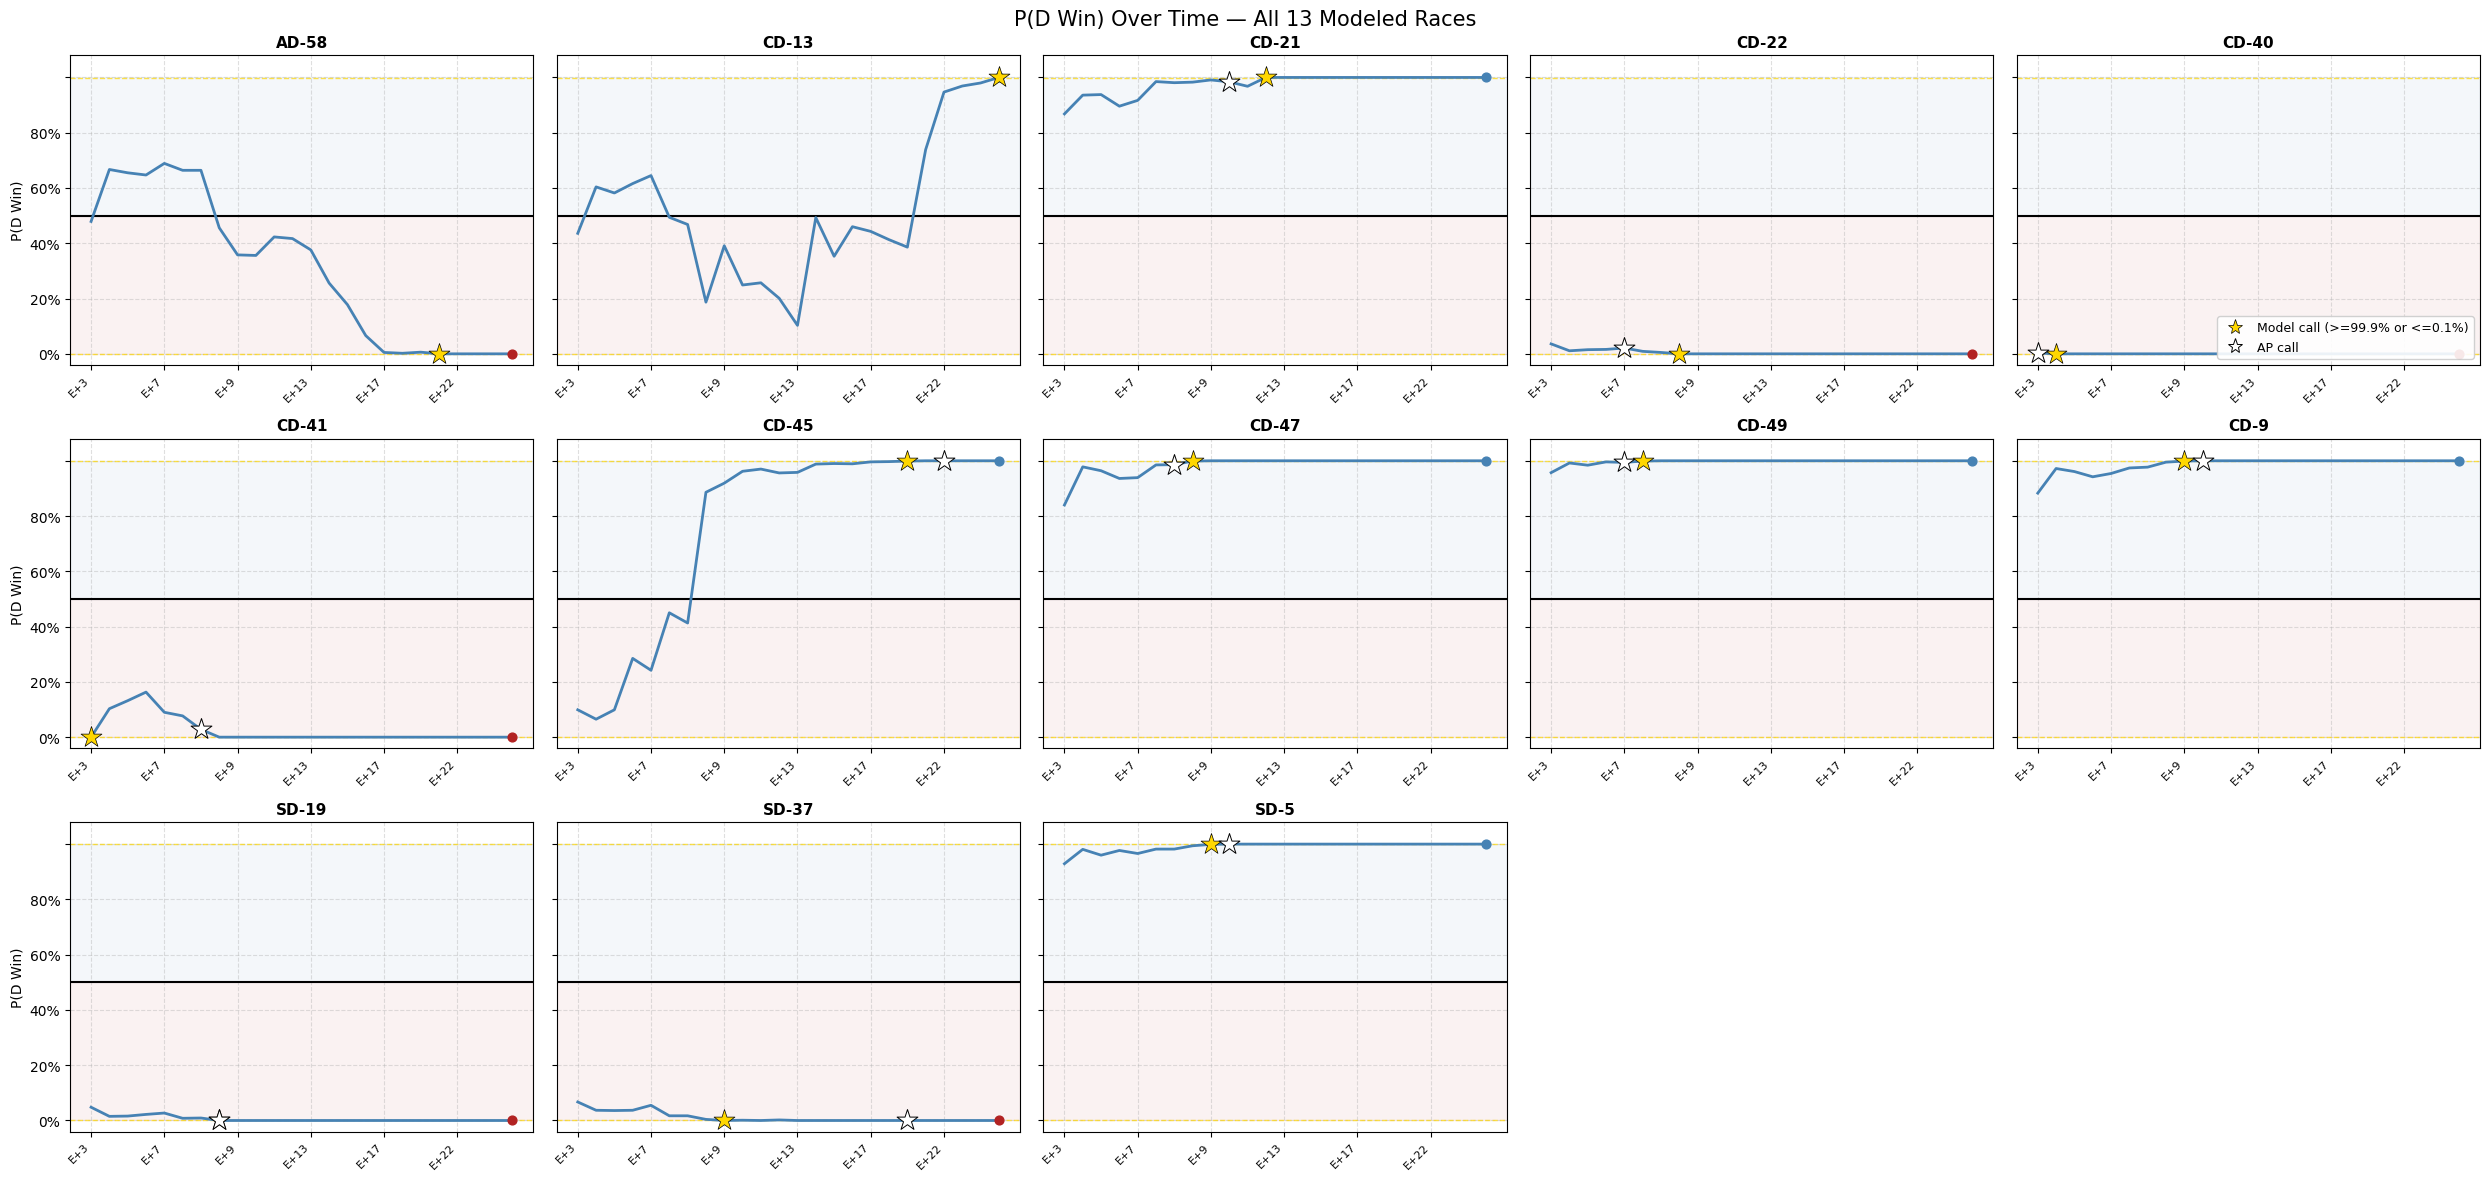

In [ ]:
cols_n = 5
rows_n = int(np.ceil(len(id_to_race) / cols_n))
fig, axes = plt.subplots(rows_n, cols_n, figsize=(5 * cols_n, 4 * rows_n),
                         sharey=True, squeeze=False)

plotted_batches = batch_list
tick_positions  = list(range(0, max(plotted_batches) + 1, 4))
tick_labels     = [f"E+{batch_ei[b]}" for b in tick_positions]

for ax_idx, race_idx in enumerate(sorted(id_to_race.keys())):
    ax        = axes[ax_idx // cols_n][ax_idx % cols_n]
    race_name = id_to_race[race_idx]
    race_denominator  = race_denominators[race_idx]
    actual_final_prop = race_data[race_data["race_id"] == race_idx]["final_dem_proportion"].values[0]
    dem_won = actual_final_prop > 0.5

    p_win = [np.mean(final_outcomes_dict[b][:, race_idx] / race_denominator > 0.5)
             for b in batch_list]

    # Model call: first batch crossing either threshold
    model_call_batch = None
    for b_i, b in enumerate(batch_list):
        if p_win[b_i] >= 0.999 or p_win[b_i] <= 0.001:
            model_call_batch = b
            model_call_i     = b_i
            break

    ax.axhspan(0.5, 1.0, color="steelblue", alpha=0.06)
    ax.axhspan(0.0, 0.5, color="firebrick", alpha=0.06)
    ax.axhline(0.5,   color="black", linewidth=1.5, zorder=3)
    ax.axhline(0.999, color="gold",  linewidth=1,   linestyle="--", alpha=0.7, zorder=2)
    ax.axhline(0.001, color="gold",  linewidth=1,   linestyle="--", alpha=0.7, zorder=2)

    ax.plot(plotted_batches, p_win, color="steelblue", linewidth=2, zorder=4)
    ax.scatter([plotted_batches[-1]], [p_win[-1]],
               color="steelblue" if dem_won else "firebrick", s=40, zorder=5)

    # Gold star: model call
    if model_call_batch is not None:
        ax.scatter([model_call_batch], [p_win[model_call_i]],
                   marker="*", color="gold", s=250, zorder=7, edgecolors="black", linewidths=0.5)

    # White star: AP call (nearest batch to AP call date)
    ap_date = ap_calls.get(race_name)
    if ap_date is not None:
        ap_batch = (batch_dates - ap_date).abs().idxmin()
        if ap_batch in plotted_batches:
            ap_i = list(plotted_batches).index(ap_batch)
            ax.scatter([ap_batch], [p_win[ap_i]],
                       marker="*", color="white", s=250, zorder=8, edgecolors="black", linewidths=0.7)

    ax.set_ylim(-0.04, 1.08)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}" if 0 <= y <= 1 else ""))
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)
    ax.set_title(race_name, fontsize=11, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.4)
    if ax_idx % cols_n == 0:
        ax.set_ylabel("P(D Win)", fontsize=10)

for j in range(len(id_to_race), rows_n * cols_n):
    axes[j // cols_n][j % cols_n].set_visible(False)

from matplotlib.lines import Line2D
star_legend = [
    Line2D([0],[0], marker="*", color="w", markerfacecolor="gold",  markersize=11,
           markeredgecolor="black", markeredgewidth=0.5, label="Model call (>=99.9% or <=0.1%)"),
    Line2D([0],[0], marker="*", color="w", markerfacecolor="white", markersize=11,
           markeredgecolor="black", markeredgewidth=0.7, label="AP call"),
]
axes[0][cols_n - 1].legend(handles=star_legend, fontsize=9, loc="lower right", framealpha=0.9)

plt.suptitle("P(D Win) Over Time — All 13 Modeled Races", fontsize=15)
plt.tight_layout()
plt.show()